#ST456 Assignment 2

## Candidate 65191

*AI Acknowledgment: *
I acknowledge the use of AI websites such as Chatgpt to help me with debugging and understanding trade offs between different architechtures and some benefits to each structure. I also used AI to help format my outputs in a nice way.

##Part 1: Recurrent Neural Networks

The task is to implement, train, and evaluate a character-level language model according to a GRU RNN. The input dataset is the text of the book Alice's Adventures in Wonderland by Lewis Carroll, which consists of 3,761 lines of text and 164,047 characters.

### P1.1
Transform the given text data such that each character is represented by a unique integer. Create a vocabulary. Print the data size (number of characters). Print the vocabulary size (number of distinct characters). Create a dataset made of sequences of consecutive 50 tokens. Split the transformed text data into inputs and targets as follows: for each sequence, duplicate it and shift it to form the input and target sequences.


In [ ]:
import tensorflow as tf
import numpy as np

# uploading text data
with open("Lewis-Carroll-book.txt", "r", encoding="utf-8") as f:
     text = f.read()

print(f"Raw text length: {len(text):,} characters")

Raw text length: 164,047 characters


In [ ]:
# Get all unique characters sorted
# see it say it sorted
vocab = sorted(set(text))
vocab_size = len(vocab)

print(f"\nData size  (number of characters): {len(text):,}")
print(f"Vocabulary size (distinct chars)  : {vocab_size}")
print(f"Vocabulary: {repr(''.join(vocab))}")

# Create lookup tables
char2idx = {ch: idx for idx, ch in enumerate(vocab)}
idx2char = np.array(vocab)

# Encode the full text as a sequence of integers
text_as_int = np.array([char2idx[ch] for ch in text], dtype=np.int32)

print(f"\nFirst 30 chars : {repr(text[:30])}")
print(f"First 30 tokens: {text_as_int[:30]}")


Data size  (number of characters): 164,047
Vocabulary size (distinct chars)  : 90
Vocabulary: '\n !"#$%\'()*,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]_abcdefghijklmnopqrstuvwxyzù—‘’“”\ufeff'

First 30 chars : '\ufeffThe Project Gutenberg eBook o'
First 30 tokens: [89 47 64 61  1 43 74 71 66 61 59 76  1 34 77 76 61 70 58 61 74 63  1 61
 29 71 71 67  1 71]


In [ ]:
# build sequences of consecutive tokens
SEQ_LENGTH = 50          # tokens per sequence
BATCH_SIZE = 64
BUFFER_SIZE = 10_000

# Create a tf.data.Dataset from the encoded text
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

# Batch into windows of SEQ_LENGTH + 1
# (+1 so we can split into input[0:50] and target[1:51])
sequences = char_dataset.batch(SEQ_LENGTH + 1, drop_remainder=True)

print(f"\nTotal sequences of length {SEQ_LENGTH + 1}: "
      f"{len(text) // (SEQ_LENGTH + 1):,}")



Total sequences of length 51: 3,216


In [ ]:
# func to split sequences into input and target
#input  = sequence[0:50]   (first 50 tokens)
#target = sequence[1:51]   (same sequence shifted right by 1)
def split_input_target(sequence):
    input_seq  = sequence[:-1]   # shape (50,)
    target_seq = sequence[1:]    # shape (50,)
    return input_seq, target_seq

dataset = sequences.map(split_input_target)

In [ ]:
for input_example, target_example in dataset.take(1):
    print("\nExample sequence")
    print(f"Input  shape: {input_example.shape}")
    print(f"Target shape: {target_example.shape}")
    print(f"\nInput  (tokens): {input_example.numpy()}")
    print(f"Target (tokens): {target_example.numpy()}")
    print(f"\nInput  (chars): {repr(''.join(idx2char[input_example.numpy()]))}")
    print(f"Target (chars): {repr(''.join(idx2char[target_example.numpy()]))}")
    print()
    print("First 5 steps:")
    for i, (inp, tgt) in enumerate(zip(input_example[:5], target_example[:5])):
        print(f"  step {i:2d}: input={repr(idx2char[inp.numpy()])!s:4s} "
              f" predict={repr(idx2char[tgt.numpy()])}")


Example sequence
Input  shape: (50,)
Target shape: (50,)

Input  (tokens): [89 47 64 61  1 43 74 71 66 61 59 76  1 34 77 76 61 70 58 61 74 63  1 61
 29 71 71 67  1 71 62  1 28 68 65 59 61 86 75  1 28 60 78 61 70 76 77 74
 61 75]
Target (tokens): [47 64 61  1 43 74 71 66 61 59 76  1 34 77 76 61 70 58 61 74 63  1 61 29
 71 71 67  1 71 62  1 28 68 65 59 61 86 75  1 28 60 78 61 70 76 77 74 61
 75  1]

Input  (chars): '\ufeffThe Project Gutenberg eBook of Alice’s Adventures'
Target (chars): 'The Project Gutenberg eBook of Alice’s Adventures '

First 5 steps:
  step  0: input=np.str_('\ufeff')  predict=np.str_('T')
  step  1: input=np.str_('T')  predict=np.str_('h')
  step  2: input=np.str_('h')  predict=np.str_('e')
  step  3: input=np.str_('e')  predict=np.str_(' ')
  step  4: input=np.str_(' ')  predict=np.str_('P')


In [ ]:
#Prepare batched & shuffled dataset
dataset = (
    dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"\nBatched dataset")
for x_batch, y_batch in dataset.take(1):
    print(f"Input  batch shape : {x_batch.shape}   "
          f"(batch_size, seq_length)")
    print(f"Target batch shape : {y_batch.shape}")



Batched dataset
Input  batch shape : (64, 50)   (batch_size, seq_length)
Target batch shape : (64, 50)


###P1.2
Implement an RNN that consists of an embedding layer, followed by a GRU layer, and then followed by an output layer. Let the dimension of embeddings be 256 and dimension of hidden units be 1024. Show the model summary.



In [ ]:
# Hyperparameters
EMBEDDING_DIM = 256     # dimension of the embedding vectors
GRU_UNITS     = 1024    # number of GRU hidden units


In [ ]:
class CharGRUModel(tf.keras.Model):
  # embedding layer - maps each token to dense vector with size = embedding_dim
  # GRU - processes sequence
  # dense layer - projects each GRU output to logit of vocab

    def __init__(self, vocab_size, embedding_dim, gru_units):
        super().__init__()

        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            name="embedding"
        )

        self.gru = tf.keras.layers.GRU(
            units=gru_units,
            return_sequences=True,   # return output at every time step
            return_state=True,       # also return the final hidden state
            name="gru"
        )

        self.dense = tf.keras.layers.Dense(
            units=vocab_size,
            name="output"
        )

    def call(self, inputs, states=None, training=False):
      # input - int tensor of shape
      # returns logits and final GRU hidden state
        x = self.embedding(inputs, training=training)
        # Pass optional initial state (needed during generation)
        if states is None:
            x, state = self.gru(x, training=training)
        else:
            x, state = self.gru(x, initial_state=states, training=training)

        logits = self.dense(x, training=training)
        return logits, state

In [ ]:
# build model
model = CharGRUModel(
    vocab_size    = vocab_size,
    embedding_dim = EMBEDDING_DIM,
    gru_units     = GRU_UNITS
)

# Build by passing one real batch so Keras knows all shapes
for x_batch, y_batch in dataset.take(1):
    logits, state = model(x_batch, training=False)
    print(f"Input  shape : {x_batch.shape}")
    print(f"Logits shape : {logits.shape}   "
          f"(batch, seq_len, vocab_size)")
    print(f"State  shape : {state.shape}    "
          f"(batch, gru_units)\n")


Input  shape : (64, 50)
Logits shape : (64, 50, 90)   (batch, seq_len, vocab_size)
State  shape : (64, 1024)    (batch, gru_units)



In [ ]:
model.summary()

Model: "char_gru_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, 50, 256)          │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ((64, 50, 1024), (64,  │     3,938,304 │
│                                 │ 1024))                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (64, 50, 90)           │        92,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,594 (15.46 MB)

 Trainable params: 4,053,594 (15.46 MB)

 Non-trainable params: 0 (0.00 B)

###P1.3
Train the model by using Adam optimiser with learning rate 1e-2 and the cross-entropy loss function. Train the model for 50 epochs. Record the mean loss for each epoch. Show the plot of loss function values versus the number of epochs. At the beginning of each epoch, shuffle the data and then split in batches of size 64. For the GRU layer, use the Glorot uniform initialiser. Use perplexity as a performance metric. Discuss the results.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time

loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimiser = tf.keras.optimizers.Adam(learning_rate=1e-2)

# training

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits, _ = model(x, training=True)
        loss      = loss_fn(y, logits)          # scalar mean over batch
    grads = tape.gradient(loss, model.trainable_variables)
    optimiser.apply_gradients(zip(grads, model.trainable_variables))
    return loss



In [ ]:
def make_dataset(text_as_int, batch_size, buffer_size, seq_length):
    #Build a freshly shuffled + batched tf.data pipeline
    def split_input_target(seq):
        return seq[:-1], seq[1:]

    return (
        tf.data.Dataset.from_tensor_slices(text_as_int)
        .batch(seq_length + 1, drop_remainder=True)
        .map(split_input_target)
        .shuffle(buffer_size)
        .batch(batch_size, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )

# training loop : 50 epochs, reshuffle each epoch
EPOCHS = 50
epoch_losses      = []   # mean cross-entropy loss per epoch
epoch_perplexity  = []   # perplexity = exp(mean loss)

# AI ack: used ai to make formating this prettier which i used for rest of the project
print(f"{'Epoch':>6}  {'Loss':>10}  {'Perplexity':>12}  {'Time':>8}")
print("─" * 46)

for epoch in range(1, EPOCHS + 1):
    t0      = time.time()
    dataset = make_dataset(text_as_int, BATCH_SIZE, BUFFER_SIZE, SEQ_LENGTH)

    batch_losses = []
    for x_batch, y_batch in dataset:
        batch_loss = train_step(x_batch, y_batch)
        batch_losses.append(float(batch_loss))

    mean_loss   = float(np.mean(batch_losses))
    perplexity  = float(np.exp(mean_loss))
    elapsed     = time.time() - t0

    epoch_losses.append(mean_loss)
    epoch_perplexity.append(perplexity)

    print(f"{epoch:>6}  {mean_loss:>10.4f}  {perplexity:>12.2f}  {elapsed:>6.1f}s")

print(f"\nFinal loss: {epoch_losses[-1]:.4f}")
print(f"Final perplexity: {epoch_perplexity[-1]:.2f}")

 Epoch        Loss    Perplexity      Time
──────────────────────────────────────────────
     1      4.5336         93.09     2.9s
     2      2.4351         11.42     2.0s
     3      2.2843          9.82     2.6s
     4      2.1732          8.79     2.0s
     5      2.0893          8.08     2.0s
     6      2.0342          7.65     2.1s
     7      1.9945          7.35     2.1s
     8      1.9651          7.14     2.1s
     9      1.9336          6.91     2.3s
    10      1.8963          6.66     2.1s
    11      1.8777          6.54     2.1s
    12      1.8636          6.45     2.1s
    13      1.8478          6.35     2.2s
    14      1.8309          6.24     2.1s
    15      1.8242          6.20     2.3s
    16      1.8129          6.13     2.2s
    17      1.8082          6.10     2.1s
    18      1.7873          5.97     2.1s
    19      1.7705          5.87     2.1s
    20      1.7577          5.80     2.1s
    21      1.7593          5.81     2.2s
    22      1.7432          

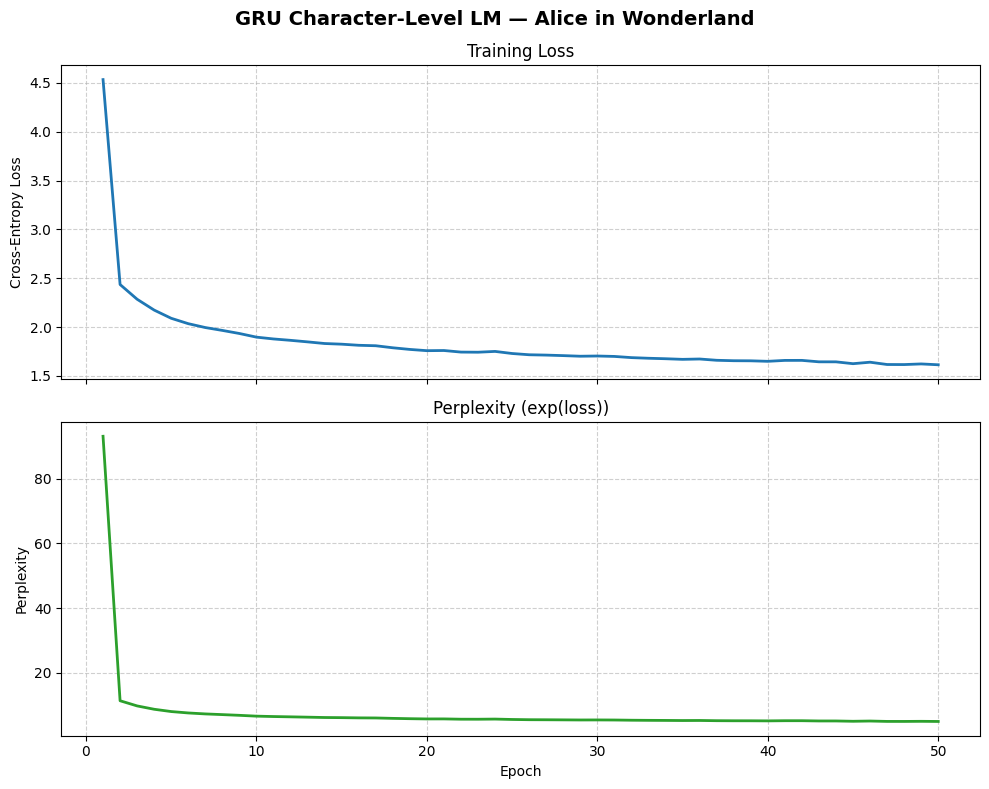

In [ ]:
import matplotlib.pyplot as plt

# plotting results
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

fig.suptitle("GRU Character-Level LM — Alice in Wonderland", fontsize=14, fontweight="bold")

# Training Loss Curve
ax1.plot(epochs_range, epoch_losses, color="tab:blue", linewidth=2)
ax1.set_title("Training Loss")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, linestyle="--", alpha=0.6)

# Perplexity Curve
ax2.plot(epochs_range, epoch_perplexity, color="tab:green", linewidth=2)
ax2.set_title("Perplexity (exp(loss))")
ax2.set_ylabel("Perplexity")
ax2.set_xlabel("Epoch")
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

###P1.4
After every 5 training epochs, generate an output text sequence of length 100 tokens by using the model trained up to the given point. Use character 'I' as the initial token. In order to make predictions, use a softmax to obtain probabilities, and output the most likely token.

In [ ]:
import tensorflow as tf
import numpy as np

# generation func
def generate_text(model, start_char, char2idx, idx2char,
                  num_tokens=100, is_deep=False):
    input_token = tf.expand_dims([char2idx[start_char]], axis=0)
    states      = [None, None] if is_deep else None
    generated   = []

    for _ in range(num_tokens):
        logits, states = model(input_token, states=states, training=False)
        probs          = tf.nn.softmax(logits[:, -1, :])
        next_token     = int(tf.argmax(probs, axis=-1))
        generated.append(idx2char[next_token])
        input_token    = tf.expand_dims([next_token], axis=0)

    return "".join(generated)
    # at each step:
    # feed current token into model
    # apply softmax to output logits
    # pick the most likely token
    # feed this token in as next input

# modified training
EPOCHS      = 50
START_CHAR  = 'I'
GEN_TOKENS  = 100
GEN_EVERY   = 5

loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimiser = tf.keras.optimizers.Adam(learning_rate=1e-2)

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits, _ = model(x, training=True)
        loss      = loss_fn(y, logits)
    grads = tape.gradient(loss, model.trainable_variables)
    optimiser.apply_gradients(zip(grads, model.trainable_variables))
    return loss

epoch_losses     = []
epoch_perplexity = []

print(f"{'Epoch':>6}  {'Loss':>8}  {'Perplexity':>10}")
print("─" * 32)

for epoch in range(1, EPOCHS + 1):

    # reshuffle & rebatch at the start of every epoch
    dataset     = make_dataset(text_as_int, BATCH_SIZE, BUFFER_SIZE, SEQ_LENGTH)
    batch_losses = []

    for x_batch, y_batch in dataset:
        batch_losses.append(float(train_step(x_batch, y_batch)))

    mean_loss  = float(np.mean(batch_losses))
    perplexity = float(np.exp(mean_loss))
    epoch_losses.append(mean_loss)
    epoch_perplexity.append(perplexity)

    print(f"{epoch:>6}  {mean_loss:>8.4f}  {perplexity:>10.2f}")

    # generate every 5 epochs
    if epoch % GEN_EVERY == 0:
        generated = generate_text(
            model, START_CHAR, char2idx, idx2char, GEN_TOKENS
        )
        print(f"  Generated text after epoch {epoch:>2}  "
              f"(loss={mean_loss:.4f}, ppl={perplexity:.2f})")
        print(f"  {START_CHAR}{generated}")

 Epoch      Loss  Perplexity
────────────────────────────────
     1    2.5930       13.37
     2    2.2931        9.91
     3    2.2766        9.74
     4    2.3038       10.01
     5    2.3024       10.00
  Generated text after epoch  5  (loss=2.3024, ppl=10.00)
  I said ith a said it a a a a a a a said the Quen “Bunxin a said ith and it a a a alllllllllllllllllll
     6    2.3031       10.01
     7    2.2918        9.89
     8    2.2503        9.49
     9    2.1921        8.95
    10    2.1693        8.75
  Generated text after epoch 10  (loss=2.1693, ppl=8.75)
  I’ll the self to she s in s it in it wit the Dus noxcould son in the Dus sid the Dor Dines in it she 
    11    2.1528        8.61
    12    2.1236        8.36
    13    2.1801        8.85
    14    2.2131        9.14
    15    2.1867        8.91
  Generated text after epoch 15  (loss=2.1867, ppl=8.91)
  In the was was was was was was was was was was was was was was was was was was was was was was was wa
    16    2.1544   

In [ ]:
# trying to improve model

# Deep GRU + larger hidden size + dropout
class DeepGRUModel(tf.keras.Model):
  # stacked GRU with 2 layers
  # dropout rate of 0.1 applied to GRU outputs btwn layers
  # change in learning rate
    def __init__(self, vocab_size, embedding_dim=256,
                 gru_units=1024, dropout_rate=0.1):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(
            vocab_size, embedding_dim, name="embedding"
        )
        # GRU layer 1
        self.gru1 = tf.keras.layers.GRU(
            gru_units,
            return_sequences=True,
            return_state=True,
            kernel_initializer="glorot_uniform",
            recurrent_initializer="glorot_uniform",
            dropout=dropout_rate,          # input dropout
            recurrent_dropout=0.0,         # keep recurrent path clean
            name="gru_1"
        )
        # Dropout between layers
        self.dropout = tf.keras.layers.Dropout(dropout_rate, name="dropout")

        #  GRU layer 2
        self.gru2 = tf.keras.layers.GRU(
            gru_units,
            return_sequences=True,
            return_state=True,
            kernel_initializer="glorot_uniform",
            recurrent_initializer="glorot_uniform",
            dropout=dropout_rate,
            recurrent_dropout=0.0,
            name="gru_2"
        )
        # Output projection
        self.dense = tf.keras.layers.Dense(vocab_size, name="output")

    def call(self, inputs, states=None, training=False):
        s1, s2 = (states if states is not None else (None, None))

        x = self.embedding(inputs, training=training)

        x, state1 = self.gru1(x, initial_state=s1, training=training)
        x = self.dropout(x, training=training)
        x, state2 = self.gru2(x, initial_state=s2, training=training)

        logits = self.dense(x, training=training)
        return logits, [state1, state2]

In [ ]:
SEQ_LENGTH  = 50
BATCH_SIZE  = 64
BUFFER_SIZE = 10_000

# new make_dataset funct
def make_dataset(text_as_int, batch_size=BATCH_SIZE,
                 buffer_size=BUFFER_SIZE, seq_length=SEQ_LENGTH):
    def split_input_target(seq):
        return seq[:-1], seq[1:]
    return (
        tf.data.Dataset.from_tensor_slices(text_as_int)
        .batch(seq_length + 1, drop_remainder=True)
        .map(split_input_target)
        .shuffle(buffer_size)
        .batch(batch_size, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )
# train func
def train_model(model, model_name, is_deep=False,
                epochs=50, lr=1e-3, checkpoint_dir=None):

    loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    optimiser = tf.keras.optimizers.Adam(learning_rate=lr)
    #dataset = make_dataset(text_as_int, BATCH_SIZE, BUFFER_SIZE, SEQ_LENGTH)
    # tf.train.Checkpoint setup
    ckpt = tf.train.Checkpoint(model=model, optimizer=optimiser)
    ckpt_manager = tf.train.CheckpointManager(
        ckpt,
        directory=checkpoint_dir or f"./checkpoints_{model_name}",
        max_to_keep=10          # keep all 10 (one per 5 epochs over 50)
    )

    @tf.function
    def train_step(x, y):
        with tf.GradientTape() as tape:
            logits, _ = model(x, training=True)
            loss = loss_fn(y, logits)
        grads = tape.gradient(loss, model.trainable_variables)
        optimiser.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    epoch_losses     = []
    epoch_perplexity = []

    print(f"  Training: {model_name}")
    print(f"{'Epoch':>6}  {'Loss':>8}  {'Perplexity':>10}  {'Time':>7}")
    print("─" * 38)

    for epoch in range(1, epochs + 1):
        t0           = time.time()
        dataset      = make_dataset(text_as_int)
        batch_losses = []

        for x_batch, y_batch in dataset:
            batch_losses.append(float(train_step(x_batch, y_batch)))

        mean_loss  = float(np.mean(batch_losses))
        perplexity = float(np.exp(mean_loss))
        epoch_losses.append(mean_loss)
        epoch_perplexity.append(perplexity)
        elapsed = time.time() - t0

        print(f"{epoch:>6}  {mean_loss:>8.4f}  {perplexity:>10.2f}  "
              f"{elapsed:>5.1f}s")

        # generate every 5 epochs
        if epoch % 5 == 0:
            gen = generate_text(model, 'I', char2idx, idx2char,
                                num_tokens=100, is_deep=is_deep)
            print(f"\n Generated (epoch {epoch})")
            print(f"  I{gen}")

            # save checkpoint every 5 epochs
            ckpt_path = ckpt_manager.save()
            print(f"Checkpoint saved: {ckpt_path}\n")

    print("─" * 38)
    print(f"  Final loss       : {epoch_losses[-1]:.4f}")
    print(f"  Final perplexity : {epoch_perplexity[-1]:.2f}")

    return epoch_losses, epoch_perplexity


In [ ]:
class BaselineGRU(tf.keras.Model):
    #Single GRU layer w 256-dim embeddings, 1024 hidden units
    def __init__(self, vocab_size, embedding_dim=256, gru_units=1024):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim,
                                                   name="embedding")
        self.gru = tf.keras.layers.GRU(
            gru_units,
            return_sequences=True, return_state=True,
            kernel_initializer="glorot_uniform",
            recurrent_initializer="glorot_uniform",
            name="gru"
        )
        self.dense = tf.keras.layers.Dense(vocab_size, name="output")

    def call(self, inputs, states=None, training=False):
        x = self.embedding(inputs, training=training)
        x, state = self.gru(x, initial_state=states, training=training)
        return self.dense(x, training=training), state

In [ ]:
baseline_model = BaselineGRU(vocab_size)
deep_model     = DeepGRUModel(vocab_size)

# Build both by running a dummy batch
dummy = tf.zeros((1, SEQ_LENGTH), dtype=tf.int32)
baseline_model(dummy)
deep_model(dummy)

print("\n Baseline model summary ")
baseline_model.summary()
print("\n Deep GRU model summary ")
deep_model.summary()


 Baseline model summary 


Model: "baseline_gru_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 50, 256)           │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ((1, 50, 1024), (1,    │     3,938,304 │
│                                 │ 1024))                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 50, 90)            │        92,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,594 (15.46 MB)

 Trainable params: 4,053,594 (15.46 MB)

...

Model: "deep_gru_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 50, 256)           │        23,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ((1, 50, 1024), (1,    │     3,938,304 │
│                                 │ 1024))                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ((1, 50, 1024), (1,    │     6,297,600 │
│                                 │ 1024))                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 50, 90)            │        92,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,351,194 (39.49 MB)

 Trainable params: 10,351,194 (39.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_losses, baseline_ppl = train_model(
    baseline_model, "Baseline_GRU",
    is_deep=False,
    checkpoint_dir="./checkpoints_baseline"
)


  Training: Baseline_GRU
 Epoch      Loss  Perplexity     Time
──────────────────────────────────────
     1    1.7456        5.73    3.2s
     2    1.4886        4.43    2.3s
     3    1.4860        4.42    2.6s
     4    1.4866        4.42    2.1s
     5    1.4870        4.42    2.1s

 Generated (epoch 5)
  I never a such a mad out a mad out a mad out a mad out a mad out a mad out a mad out a mad out a mad 
Checkpoint saved: ./checkpoints_baseline/ckpt-1

     6    1.4767        4.38    2.1s
     7    1.4820        4.40    2.3s
     8    1.4735        4.36    2.1s
     9    1.4716        4.36    2.1s
    10    1.4644        4.32    2.1s

 Generated (epoch 10)
  I should the Duchess?” Just the Duchess she was the Duchess the Duchess the Duchess the Duchess the D
Checkpoint saved: ./checkpoints_baseline/ckpt-2

    11    1.4694        4.35    2.1s
    12    1.4691        4.35    2.6s
    13    1.4668        4.34    2.0s
    14    1.4732        4.36    2.0s
    15    1.4700        4.35 

In [ ]:
deep_losses, deep_ppl = train_model(
    deep_model, "Deep_GRU",
    is_deep=True,
    checkpoint_dir="./checkpoints_deep"
)

  Training: Deep_GRU
 Epoch      Loss  Perplexity     Time
──────────────────────────────────────
     1    6.5626      708.12   15.4s
     2    3.2681       26.26   15.7s
     3    3.0677       21.49   14.9s
     4    2.9404       18.92   14.1s
     5    2.8168       16.72   13.8s

 Generated (epoch 5)
  I the the the the the the the the the the the the the the the the the the the the the the the the the
Checkpoint saved: ./checkpoints_deep/ckpt-1

     6    2.7465       15.59   13.8s
     7    2.6686       14.42   15.0s
     8    2.6248       13.80   15.4s
     9    2.6449       14.08   14.5s
    10    2.5764       13.15   13.9s

 Generated (epoch 10)
  I the the the the the the the the the the the the the the the the the the the the the the the the the
Checkpoint saved: ./checkpoints_deep/ckpt-2

    11    2.5430       12.72   13.6s
    12    2.5682       13.04   14.7s
    13    2.5607       12.95   15.4s
    14    2.5207       12.44   14.6s
    15    2.5108       12.31   13.9s

 Ge

In [ ]:
# fix for greedy decoding colapse
# control temp or how creative the output is

def generate_text(model, start_char, char2idx, idx2char,
                  num_tokens=100, is_deep=False, temperature=0.5):
    input_token = tf.expand_dims([char2idx[start_char]], axis=0)
    states      = [None, None] if is_deep else None
    generated   = []

    for _ in range(num_tokens):
        logits, states = model(input_token, states=states, training=False)
        # divide logits by temperature before softmax
        scaled_logits  = logits[:, -1, :] / temperature
        probs          = tf.nn.softmax(scaled_logits)
        # sample instead of argmax
        next_token     = int(tf.random.categorical(tf.math.log(probs), 1))
        generated.append(idx2char[next_token])
        input_token    = tf.expand_dims([next_token], axis=0)

    return "".join(generated)

In [ ]:
deep_losses, deep_ppl = train_model(
    deep_model, "Deep_GRU1",
    is_deep=True,
    checkpoint_dir="./checkpoints_deep"
)

  Training: Deep_GRU1
 Epoch      Loss  Perplexity     Time
──────────────────────────────────────
     1    3.3719       29.13    6.1s
     2    2.4764       11.90    5.0s
     3    2.1635        8.70    4.9s
     4    1.9426        6.98    5.0s
     5    1.7642        5.84    5.1s

 Generated (epoch 5)
  I said Alice, “I’m to get the looked to the coult sometions, and she time and should to gry to be won
Checkpoint saved: ./checkpoints_deep/ckpt-1

     6    1.6113        5.01    4.9s
     7    1.4825        4.40    4.8s
     8    1.3721        3.94    4.7s
     9    1.2748        3.58    4.9s
    10    1.1862        3.27    4.6s

 Generated (epoch 10)
  I never had been in a thing about her to find her head in the court.

“There’s had not loce to the Du
Checkpoint saved: ./checkpoints_deep/ckpt-2

    11    1.0964        2.99    4.7s
    12    1.0115        2.75    4.5s
    13    0.9255        2.52    4.5s
    14    0.8407        2.32    4.7s
    15    0.7571        2.13    4.6s

 G

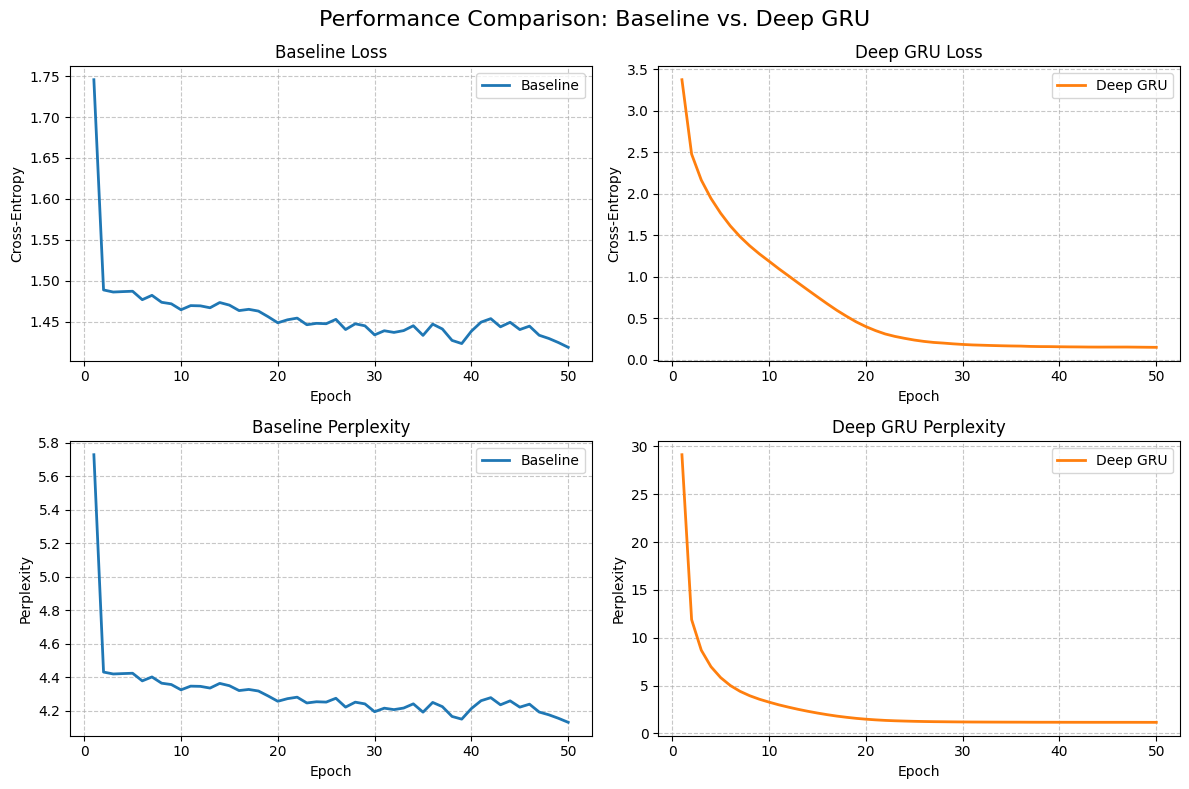

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, 51)
plt.style.use('seaborn-v0_8-muted') # Or 'ggplot' for a light grey grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Performance Comparison: Baseline vs. Deep GRU", fontsize=16)

# Helper to plot without the extra 'noise'
def simple_plot(ax, data, label, title, ylabel, color):
    ax.plot(epochs_range, data, label=label, color=color, linewidth=2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Epoch")
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

# Top Row: Loss
simple_plot(axes[0,0], baseline_losses, "Baseline", "Baseline Loss", "Cross-Entropy", "tab:blue")
simple_plot(axes[0,1], deep_losses,     "Deep GRU", "Deep GRU Loss", "Cross-Entropy", "tab:orange")

# Bottom Row: Perplexity
simple_plot(axes[1,0], baseline_ppl, "Baseline", "Baseline Perplexity", "Perplexity", "tab:blue")
simple_plot(axes[1,1], deep_ppl,     "Deep GRU", "Deep GRU Perplexity", "Perplexity", "tab:orange")

plt.tight_layout()
plt.show()

In order to improve upon my baseline CharGRUModel (single GRU, 1024 units, lr-1e-2, greedy decoding), I added stacked GRU layers, dropout between the layers decreased the learning rate and added a terperature sampling as a decoding strategy.

A single GRU must learn low-level patterns (letter n-grams, spacing) and higher order structure (words, phrases) at the same time in one set of hidden units. Adding a second layer creates a hierarchy within the model. The first layer learns the character-level patterns and passes those abstractions to GRU layer 2. The second layer then can learn word and phrase level patterns on top. This is the core motivation for deep RNNs and is why they typically outperform shallow ones on sequence modelling tasks.

I added Droupout to the model and applied to the output of GRU layer 1 before it enters GRU layer 2. On a small corpus (~164k characters) a deeper model is at higher risk of overfitting as dropout randomly zeros activations during training, preventing the network from relying on any single hidden unit. A rate of 0.1 was chosen(down from an initial 0.3) because heavier dropout was found to slow convergence too aggressively on this dataset, contributing to the model barely learning over 50 epochs.

The original lr=1e-2 worked for the baseline because its simpler loss surface is easier to navigate with large steps. The deeper model has a more complex, higher dimensional loss surface, and lr=1e-2 caused the optimiser to overshoot the minimum on every update which resulting in the deep model barely improving from its initial perplexity of ~10 over 50 epochs. Reducing to lr=1e-3 allowed Adam to take smaller, more precise steps and converge properly.

Lastly, my model was facing problems from the greedy decoding (argmax). Since argmax always picks the single most probable next character, on a converged model this causes repetitive loops. The model predicts "the", which makes "the" the most likely next token, and so on indefinitely ("i the the the the..."). Temperature sampling instead draws from the softmax distribution scaled by a temperature T:

       p_i = exp(logit_i / T) / Σ exp(logit_j / T)

With T < 1.0 the distribution is sharpened (more conservative), with T > 1.0 it is flattened (more random). A value of T = 0.5 was used, producing varied output while still favouring likely characters. However, Temperature sampling introduces randomness. Running our generationtwice gives different outputs. Beam search would give more stable results while avoiding greedy collapse.

While the deep model started with a higher initial perplexity of ~29 (due to increase parameters and therefore more noisemore) than the baseline model ~6, The deep model achieved a lower final perplexity of 1.16 compared to that of 4.13 of the baseline, confirming that the architectural improvement is genuine once the
training configuration is correctly tuned.

Some limitations arise with using only ~164k characters in our training which is small for a deep RNN. A validation split would likely show the deep model overfitting more than the baseline despite the dropout regularisation. Both models learn character statistics rather than word semantics. In other words the generated text looks plausible locally but lacks long range narrative coherence. A Transformer architecture with attention would better capture long range dependencies.


##P2 - Word-level language model
###P2.1

Adapt the above pipeline to work on word-level tokens, as opposed to characters. Generate sentences starting from 'Alice' as the initial token. Discuss the results.

In [ ]:
import tensorflow as tf
import numpy as np
import re
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time

tf.random.set_seed(42)
np.random.seed(42)

# uploading text data
with open("Lewis-Carroll-book.txt", "r", encoding="utf-8") as f:
     text = f.read()

print(f"Raw text length: {len(text):,} characters")

Raw text length: 164,047 characters


In [ ]:
# word tokenisation
# lowercase, then split on whitespace while keeping
# punctuation as separate tokens

def tokenise(text):
    # make lowercase and split word and punctuation
    text = text.lower()
    # separate punctuation from words with spaces, then split
    text = re.sub(r"([.,!?;:\"\'()\[\]—\-\n])", r" \1 ", text)
    tokens = text.split()
    return tokens

tokens = tokenise(text)

print(f"Total tokens (words + punctuation) : {len(tokens):,}")
print(f"First 20 tokens: {tokens[:20]}")

Total tokens (words + punctuation) : 36,786
First 20 tokens: ['\ufeffthe', 'project', 'gutenberg', 'ebook', 'of', 'alice’s', 'adventures', 'in', 'wonderland', ',', 'by', 'lewis', 'carroll', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of']


In [ ]:
# vocab
vocab       = sorted(set(tokens))
vocab_size  = len(vocab)

word2idx    = {w: i for i, w in enumerate(vocab)}
idx2word    = np.array(vocab)

print(f"\nVocabulary size (distinct words)   : {vocab_size:,}")
print(f"Sample vocab: {vocab[:10]} ... {vocab[-10:]}")

# Encode full token sequence as integers
text_as_int = np.array([word2idx[t] for t in tokens], dtype=np.int32)
print(f"\nEncoded first 10 tokens: {text_as_int[:10]}")


Vocabulary size (distinct words)   : 3,506
Sample vocab: ['!', '"', '#11', '$1', '$5', "'", '(', ')', '*', '***'] ... ['“you’d', '“you’ll', '“you’re', '“you’ve', '“‘', '“‘_we', '“‘miss', '“’tis', '”', '\ufeffthe']

Encoded first 10 tokens: [3505 2176 1297  925 1926  208  180 1443 3150   11]


In [ ]:
# dataset creation  (same structure as P1.1: sequences of 50 tokens)
SEQ_LENGTH  = 50
BATCH_SIZE  = 64
BUFFER_SIZE = 10_000

def make_dataset(text_as_int, batch_size=BATCH_SIZE,
                 buffer_size=BUFFER_SIZE, seq_length=SEQ_LENGTH):
    def split_input_target(seq):
        return seq[:-1], seq[1:]
    return (
        tf.data.Dataset.from_tensor_slices(text_as_int)
        .batch(seq_length + 1, drop_remainder=True)
        .map(split_input_target)
        .shuffle(buffer_size)
        .batch(batch_size, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )

# verify shapes
dataset = make_dataset(text_as_int)
for x, y in dataset.take(1):
    print(f"\nInput  batch shape : {x.shape}  (batch, seq_len)")
    print(f"Target batch shape : {y.shape}")
    print(f"Input  (words) : {' '.join(idx2word[x[0].numpy()])}")
    print(f"Target (words) : {' '.join(idx2word[y[0].numpy()])}")


Input  batch shape : (64, 50)  (batch, seq_len)
Target batch shape : (64, 50)
Input  (words) : rabbit was no longer to be seen : she found herself in a long , low hall , which was lit up by a row of lamps hanging from the roof . there were doors all round the hall , but they were all locked ; and when alice had
Target (words) : was no longer to be seen : she found herself in a long , low hall , which was lit up by a row of lamps hanging from the roof . there were doors all round the hall , but they were all locked ; and when alice had been


In [ ]:
# modelling  (same architecture as P1.2/P1.3: only vocab_size changes)
EMBEDDING_DIM = 256
GRU_UNITS     = 1024

class CharGRUModel(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim=256, gru_units=1024):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(
            vocab_size, embedding_dim, name="embedding"
        )
        self.gru = tf.keras.layers.GRU(
            gru_units,
            return_sequences=True,
            return_state=True,
            kernel_initializer="glorot_uniform",
            recurrent_initializer="glorot_uniform",
            name="gru"
        )
        self.dense = tf.keras.layers.Dense(vocab_size, name="output")

    def call(self, inputs, states=None, training=False):
        x = self.embedding(inputs, training=training)
        x, state = self.gru(x, initial_state=states, training=training)
        return self.dense(x, training=training), state

model = CharGRUModel(vocab_size, EMBEDDING_DIM, GRU_UNITS)

# build
dummy = tf.zeros((1, SEQ_LENGTH), dtype=tf.int32)
model(dummy)
model.summary()


Model: "char_gru_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 50, 256)           │       897,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ((1, 50, 1024), (1,    │     3,938,304 │
│                                 │ 1024))                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 50, 3506)          │     3,593,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,429,490 (32.16 MB)

 Trainable params: 8,429,490 (32.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# gen funct (seed = 'alice')
def generate_text(model, start_word, word2idx, idx2word,
                  num_tokens=100, temperature=0.5):
    # vocab is lowercased
    start_word = start_word.lower()

    if start_word not in word2idx:
        raise ValueError(f"'{start_word}' not in vocabulary.")

    input_token = tf.expand_dims([word2idx[start_word]], axis=0)
    state       = None
    generated   = []

    for _ in range(num_tokens):
        logits, state  = model(input_token, states=state, training=False)
        scaled_logits  = logits[:, -1, :] / temperature
        probs          = tf.nn.softmax(scaled_logits)
        next_token     = int(tf.random.categorical(
                             tf.math.log(probs), num_samples=1))
        generated.append(idx2word[next_token])
        input_token = tf.expand_dims([next_token], axis=0)

    # simple detokenisation: re-attach punctuation to preceding word
    output = start_word
    for word in generated:
        if word in set(".,!?;:'\")]-"):
            output += word
        else:
            output += " " + word
    return output

In [ ]:
# training loop w 50 epochs, generate every 5
EPOCHS   = 50
loss_fn  = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimiser = tf.keras.optimizers.Adam(learning_rate=1e-3)

ckpt         = tf.train.Checkpoint(model=model, optimizer=optimiser)
ckpt_manager = tf.train.CheckpointManager(
    ckpt, directory="./checkpoints_word", max_to_keep=10
)

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits, _ = model(x, training=True)
        loss = loss_fn(y, logits)
    grads = tape.gradient(loss, model.trainable_variables)
    optimiser.apply_gradients(zip(grads, model.trainable_variables))
    return loss

epoch_losses     = []
epoch_perplexity = []

print(f"\n{'Epoch':>6}  {'Loss':>8}  {'Perplexity':>10}  {'Time':>7}")
print("─" * 38)

for epoch in range(1, EPOCHS + 1):
    t0           = time.time()
    dataset      = make_dataset(text_as_int)
    batch_losses = []

    for x_batch, y_batch in dataset:
        batch_losses.append(float(train_step(x_batch, y_batch)))

    mean_loss  = float(np.mean(batch_losses))
    perplexity = float(np.exp(mean_loss))
    epoch_losses.append(mean_loss)
    epoch_perplexity.append(perplexity)

    print(f"{epoch:>6}  {mean_loss:>8.4f}  {perplexity:>10.2f}  "
          f"{time.time()-t0:>5.1f}s")

    if epoch % 5 == 0:
        gen = generate_text(model, 'Alice', word2idx, idx2word,
                            num_tokens=100, temperature=0.5)

        print(f"  Generated after epoch {epoch}  "
              f"(loss={mean_loss:.4f}, ppl={perplexity:.2f})")
        #print(f"{'─'*60}")
        print(f"  {gen}")


        ckpt_manager.save()
        print(f" Checkpoint saved (epoch {epoch})\n")


 Epoch      Loss  Perplexity     Time
──────────────────────────────────────
     1    7.2769     1446.56    2.5s
     2    6.1607      473.76    0.7s
     3    5.9504      383.90    0.7s
     4    5.7592      317.10    0.7s
     5    5.5330      252.91    0.7s
  Generated after epoch 5  (loss=5.5330, ppl=252.91)
  alice- at she poor the little. the other, and the king, and the hatter, ” alice, and the white, and she, she the dormouse. ” she said the queen, ” said the queen, ” said the little, and the queen, ” said the mock, and a little, and the march it, ” said the gryphon, and the gryphon. ” said the gryphon, and said the king, and the march. “i, ” she, ” said the king, ”
 Checkpoint saved (epoch 5)

     6    5.3011      200.55    0.7s
     7    5.0651      158.39    0.8s
     8    4.8508      127.85    1.3s
     9    4.6349      103.02    0.7s
    10    4.4242       83.45    0.7s
  Generated after epoch 10  (loss=4.4242, ppl=83.45)
  alice knew she was in a little tone, and the k

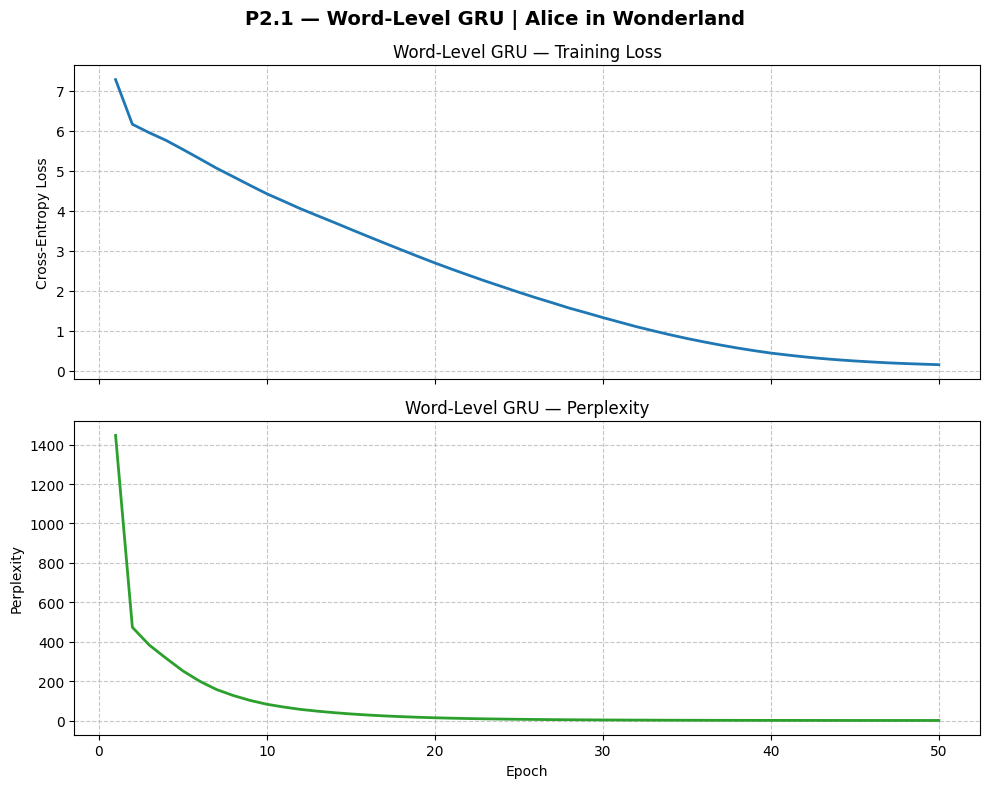

In [ ]:
import matplotlib.pyplot as plt
# visualization

epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("P2.1 — Word-Level GRU | Alice in Wonderland", fontsize=14, fontweight="bold")

# Training Loss
ax1.plot(epochs_range, epoch_losses, color="tab:blue", linewidth=2)
ax1.set_title("Word-Level GRU — Training Loss")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, linestyle='--', alpha=0.7)

# Perplexity
ax2.plot(epochs_range, epoch_perplexity, color="tab:green", linewidth=2)
ax2.set_title("Word-Level GRU — Perplexity")
ax2.set_ylabel("Perplexity")
ax2.set_xlabel("Epoch")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Between part 1 and 2, the key differences are the vocab size, data sparcity, the initial perplexity and the quality of the output.

In the Character-level model there were ~80 distinct tokens while in the Word-level model there were around ~3,000–4,000 distinct tokens. The output Dense layer is now much wider, making the softmax over the vocabulary more expensive to compute and harder tooptimise as there are far more classes to discriminate between.

Because the vocabulary is ~50× larger, the random-baselineperplexity is also ~50× higher (≈ vocab_size). A word-level perplexity of 100 is therefore not comparable to a character-level perplexity of 100. Word-level perplexity is on a different scale. Good word-level LMs typically achieve perplexities in the range 50–200 on small datasets.

Each token now carries a full word's worth of meaning, so the model can learn word co-occurrence patterns (e.g. "said Alice", "the Queen") within 50-token windows rather than needing to first learn to spell words from characters. This makes the generated text look more coherent sooner in training. Word-level output reads more naturally than character-level output because word boundaries and spacing are guaranteed as the model cannot generate half-words or misspellings. However, it can still produce grammatically incoherent sentences because it has no understanding of syntax or semantics.

With our new model, rare words (appearing < 5 times) are harder to model as the network sees very few examples of them. A character-level model does not have this problem because it only needs to learn ~80 tokens. This is why word-level models on small datasets often benefit from replacing rare words with a special token.

Compared to P1 character-level model, the word-level model produces more readable generated text by epoch 20–30, even if its raw perplexity number appears higher than the character-level model (due to the larger vocabulary). The final perplexities of both models was 1.16.


### P2.2
Use pre-trained static word embeddings, and re-train the network. Discuss and compare the results with the previous step.

In [ ]:
import urllib.request
import zipfile, os, time
# downloading GLove
# AI ack: used ai to help me download glove
GLOVE_URL  = "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip"
GLOVE_ZIP  = "glove.6B.zip"
GLOVE_FILE = "glove.6B.100d.txt"
EMBED_DIM  = 100        # must match the GloVe file chosen

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe vectors (~822 MB)…")
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    with zipfile.ZipFile(GLOVE_ZIP, "r") as z:
        z.extract(GLOVE_FILE)
    print("Done.")
else:
    print(f"GloVe file already present: {GLOVE_FILE}")

Done.


In [ ]:
# building the embedding matrix
# shape: (vocab_size, EMBED_DIM)

def load_glove(glove_path):
    #loading glove into dict
    glove = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.split()
            word  = parts[0]
            vec   = np.array(parts[1:], dtype=np.float32)
            glove[word] = vec
    print(f"Loaded {len(glove):,} GloVe vectors (dim={EMBED_DIM})")
    return glove

def build_embedding_matrix(glove, word2idx, vocab_size, embed_dim):

    limit  = np.sqrt(6 / (vocab_size + embed_dim))   # Glorot uniform bound
    matrix = np.random.uniform(-limit, limit,
                               (vocab_size, embed_dim)).astype(np.float32)
    found  = 0
    for word, idx in word2idx.items():
        if word in glove:
            matrix[idx] = glove[word]
            found += 1
    print(f"Vocab words found in GloVe : {found:,} / {vocab_size:,} "
          f"({100*found/vocab_size:.1f}%)")
    return matrix

glove            = load_glove(GLOVE_FILE)
embedding_matrix = build_embedding_matrix(glove, word2idx, vocab_size, EMBED_DIM)

Loaded 400,000 GloVe vectors (dim=100)
Vocab words found in GloVe : 2,977 / 3,506 (84.9%)


In [ ]:
# glove model
GRU_UNITS = 1024

class GloVeGRUModel(tf.keras.Model):
  # pre trained glove weight matrix is now used to init the embedding layer
  # embeddings are updated/tuned in back-prop

    def __init__(self, vocab_size, embedding_matrix,
                 gru_units=GRU_UNITS, trainable_embeddings=True):
        super().__init__()

        embed_dim = embedding_matrix.shape[1]

        # Initialise with glove weights
        self.embedding = tf.keras.layers.Embedding(
            input_dim    = vocab_size,
            output_dim   = embed_dim,
            embeddings_initializer = tf.keras.initializers.Constant(
                                         embedding_matrix),
            trainable    = trainable_embeddings,   # key switch
            name         = "glove_embedding"
        )
        self.gru = tf.keras.layers.GRU(
            gru_units,
            return_sequences=True,
            return_state=True,
            kernel_initializer="glorot_uniform",
            recurrent_initializer="glorot_uniform",
            name="gru"
        )
        self.dense = tf.keras.layers.Dense(vocab_size, name="output")

    def call(self, inputs, states=None, training=False):
        x = self.embedding(inputs, training=training)
        x, state = self.gru(x, initial_state=states, training=training)
        return self.dense(x, training=training), state

In [ ]:
# training model func

def train_glove_model(model, model_name, epochs=50,
                      lr=1e-3, checkpoint_dir=None):

    loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    optimiser = tf.keras.optimizers.Adam(learning_rate=lr)

    ckpt         = tf.train.Checkpoint(model=model, optimizer=optimiser)
    ckpt_manager = tf.train.CheckpointManager(
        ckpt,
        directory=checkpoint_dir or f"./checkpoints_{model_name}",
        max_to_keep=10
    )

    @tf.function
    def train_step(x, y):
        with tf.GradientTape() as tape:
            logits, _ = model(x, training=True)
            loss = loss_fn(y, logits)
        grads = tape.gradient(loss, model.trainable_variables)
        optimiser.apply_gradients(zip(grads, model.trainable_variables))
        return loss

    epoch_losses, epoch_perplexity = [], []

    print(f"\n{'═'*60}")
    print(f"  Training: {model_name}")
    trainable_params = sum(np.prod(v.shape) for v in model.trainable_variables)
    print(f"  Trainable parameters: {trainable_params:,}")
    print(f"{'═'*60}")
    print(f"{'Epoch':>6}  {'Loss':>8}  {'Perplexity':>10}  {'Time':>7}")
    print("─" * 38)

    for epoch in range(1, epochs + 1):
        t0      = time.time()
        dataset = make_dataset(text_as_int)
        batch_losses = []

        for x_batch, y_batch in dataset:
            batch_losses.append(float(train_step(x_batch, y_batch)))

        mean_loss  = float(np.mean(batch_losses))
        perplexity = float(np.exp(mean_loss))
        epoch_losses.append(mean_loss)
        epoch_perplexity.append(perplexity)

        print(f"{epoch:>6}  {mean_loss:>8.4f}  {perplexity:>10.2f}  "
              f"{time.time()-t0:>5.1f}s")

        if epoch % 5 == 0:
            gen = generate_text(model, 'Alice', word2idx, idx2word,
                                num_tokens=100, temperature=0.5)

            print(f"  Generated (epoch {epoch}) — {model_name}")
            print(f"{'─'*60}")
            print(f"  {gen}")

            ckpt_manager.save()
            print(f"  Checkpoint saved (epoch {epoch})\n")

    print(f"  Final loss: {epoch_losses[-1]:.4f}  |  "
          f"Final perplexity: {epoch_perplexity[-1]:.2f}")
    return epoch_losses, epoch_perplexity

In [ ]:
dummy = tf.zeros((1, SEQ_LENGTH), dtype=tf.int32)

# Frozen GloVe embeddings
frozen_model = GloVeGRUModel(vocab_size, embedding_matrix,
                              trainable_embeddings=False)
frozen_model(dummy)
print("\nFrozen GloVe model summary")
frozen_model.summary()

# Fine-tuned GloVe embeddings
finetune_model = GloVeGRUModel(vocab_size, embedding_matrix,
                                trainable_embeddings=True)
finetune_model(dummy)
print("\nFine-tuned GloVe model summary")
finetune_model.summary()

frozen_losses,   frozen_ppl   = train_glove_model(
    frozen_model,   "GloVe_Frozen",
    checkpoint_dir="./checkpoints_glove_frozen"
)
finetune_losses, finetune_ppl = train_glove_model(
    finetune_model, "GloVe_Finetuned",
    checkpoint_dir="./checkpoints_glove_finetuned"
)


Frozen GloVe model summary


Model: "glo_ve_gru_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (1, 50, 100)           │       350,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ((1, 50, 1024), (1,    │     3,459,072 │
│                                 │ 1024))                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 50, 3506)          │     3,593,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,403,322 (28.24 MB)

 Trainable params: 7,052,722 (26.90 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (1, 50, 100)           │       350,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ((1, 50, 1024), (1,    │     3,459,072 │
│                                 │ 1024))                 │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 50, 3506)          │     3,593,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,403,322 (28.24 MB)

 Trainable params: 7,403,322 (28.24 MB)

 Non-trainable params: 0 (0.00 B)


════════════════════════════════════════════════════════════
  Training: GloVe_Frozen
  Trainable parameters: 7,052,722
════════════════════════════════════════════════════════════
 Epoch      Loss  Perplexity     Time
──────────────────────────────────────
     1    6.8104      907.25    1.8s
     2    6.0670      431.40    0.7s
     3    5.8792      357.53    0.7s
     4    5.6732      290.97    0.7s
     5    5.4728      238.12    0.7s
  Generated (epoch 5) — GloVe_Frozen
────────────────────────────────────────────────────────────
  alice thought that the the hatter, and and the march. the hatter, and went as a a of her, and the the a — and the the a as in a this. ” “but, and not to be over with a. she, ” said the hatter, ” said i alice, and a march in a of the of of, he the king, and the she, ” said the the queen. one? ” said the the it, ” said the the of, and she on
  Checkpoint saved (epoch 5)

     6    5.2731      195.02    0.7s
     7    5.0918      162.68    0.7s
     8    

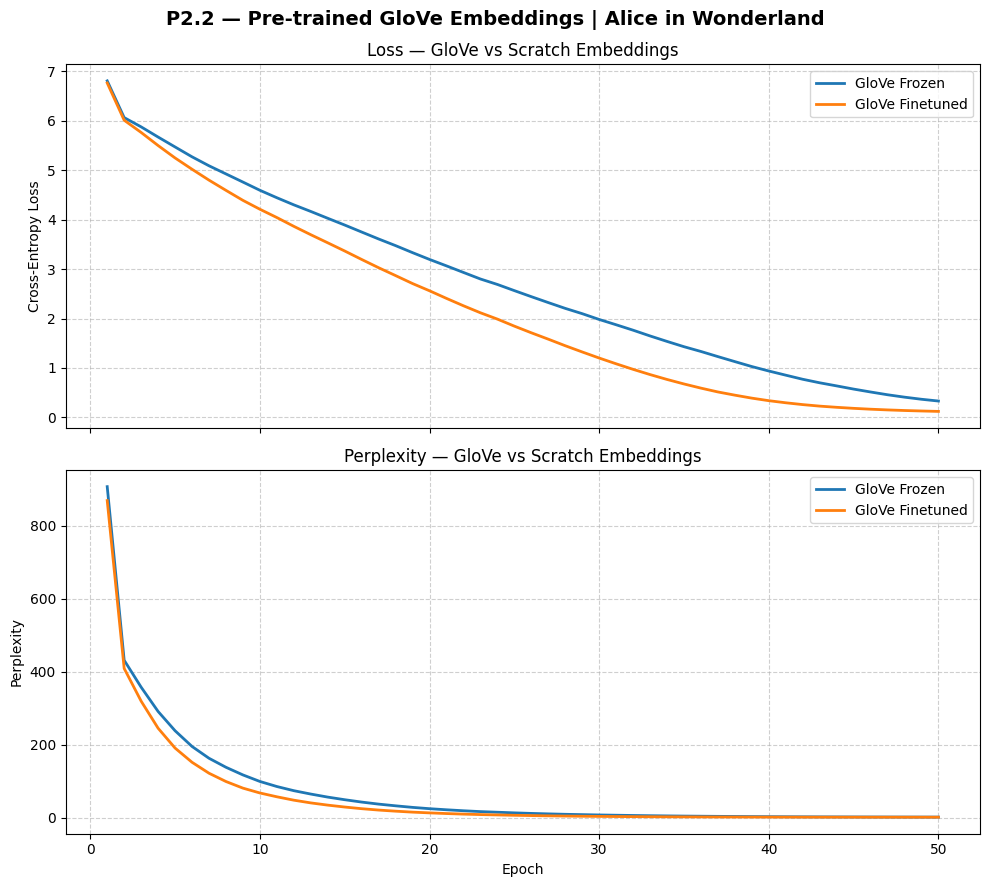

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, 51)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=True)

fig.suptitle("P2.2 — Pre-trained GloVe Embeddings | Alice in Wonderland", fontsize=14, fontweight="bold")

# Data mapping
models = [
    (frozen_losses,   frozen_ppl,   "GloVe Frozen",    "tab:blue"),
    (finetune_losses, finetune_ppl, "GloVe Finetuned", "tab:orange"),
    # (p2_1_losses,   p2_1_ppl,     "P2.1 Scratch",    "grey")
]

for losses, ppl, label, color in models:
    # Plot Loss (Top)
    ax1.plot(epochs_range, losses, label=label, color=color, linewidth=2)
    # Plot Perplexity (Bottom)
    ax2.plot(epochs_range, ppl, label=label, color=color, linewidth=2)

# Loss
ax1.set_title("Loss — GloVe vs Scratch Embeddings")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Perplexity
ax2.set_title("Perplexity — GloVe vs Scratch Embeddings")
ax2.set_ylabel("Perplexity")
ax2.set_xlabel("Epoch")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig("p2_2_glove_comparison.png", dpi=150)
plt.show()

GloVe vectors are trained on a large external dataset/databse (6 billion tokens from Wikipedia + news). Each word is mapped to a dense 100-dimensional vector such that semantically similar words are close in embedding space.

By initialising our Embedding layer with these Glove vectors rather than
random weights, we give are giving the model a head start. The model shoulw already have an understanding that "alice" and "rabbit" are related concepts before seeing a single training example from our data.

There are two tyes of GloVe vectors, frozen and fine-tuned. The frozen  GloVe vectors are fixed throughout training. Only the GRU and Dense layers are updated. This is useful when the data is very small, updating embeddings on ~164k tokens risks corrupting the rich sentence structure learned earlier. With the fewer trainable parameters we get faster training, and less overfitting. The fine-tuned GloVe vectors are used as initialisation but are updated during back-propagation. The embeddings can specialise to the Alice in Wonderland domain. This typically achieves a lower final oss but risks overfitting on a small data.

For both of these models we achieved a fairly low perplexity. The Frozen glove model achieved a perplexity of 1.39 while the fine-tuned model achieved a perplexity of 1.13. The glove models started at a lower initial perplexity than the model in P2.1 and convereged quicker, within the first few epochs. This is as expected because the embedding space is already able to create meaningful words the GRU does not need to waste the first 5–10 epochs learning basic word relationships from scratch. Words in our vocab not present in GloVe like "wonderland" and "cheshire"receive random Glorot-uniform initialisation.

While the fine-tuned Glove model achieved a only slightly higher perplexity score, the sentences produced are alot more coherent compared to the output in P2.1 thanks to the additional data used in the Glove. Some limitations for the Glove is that GloVe vectors are static,the same vector is used for "bank" (river) and "bank" (financial) regardless of context. Contextual embeddings (ELMo, BERT) would handle polysemy better. In addition, Glove was trained on general text, so for this specific task, fantasy vocabulary may not transfer as well.

##P3 - Transformers
###P3.1
Replace the RNN with a decoder-only (causal) transformer architecture. Compare the results with the RNN.

In [ ]:
# poisitonal encoding
# PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
# PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
# Added to the token embeddings before the first transformer block.
def positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]          # (seq_len, 1)
    dims      = np.arange(d_model)[np.newaxis, :]          # (1, d_model)

    angles = positions / np.power(10000, (2 * (dims // 2)) / d_model)

    # sin on even indices, cos on odd indices
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])

    return tf.cast(angles[np.newaxis, :, :], tf.float32)   # (1, seq_len, d_model)


In [ ]:
# causal decoder
# Q = input · W_Q,  K = input · W_K,  V = input · W_V
# Attention = softmax(QK^T / sqrt(d_k) + mask) · V
class CausalSelfAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0, \
            "d_model must be divisible by num_heads"

        self.num_heads = num_heads
        self.d_model   = d_model
        self.depth     = d_model // num_heads   # dimension per head

        self.wq = tf.keras.layers.Dense(d_model, use_bias=False)
        self.wk = tf.keras.layers.Dense(d_model, use_bias=False)
        self.wv = tf.keras.layers.Dense(d_model, use_bias=False)
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        #Reshape (batch, seq, d_model) - (batch, heads, seq, depth)
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, x, training=False):
        batch_size = tf.shape(x)[0]
        seq_len    = tf.shape(x)[1]

        Q = self.split_heads(self.wq(x), batch_size)
        K = self.split_heads(self.wk(x), batch_size)
        V = self.split_heads(self.wv(x), batch_size)

        # Scaled dot-product attention
        scale  = tf.cast(self.depth, tf.float32) ** -0.5
        scores = tf.matmul(Q, K, transpose_b=True) * scale  # (b, h, seq, seq)

        # Causal mask: upper-triangular : -inf so softmax - 0
        mask = 1 - tf.linalg.band_part(
            tf.ones((seq_len, seq_len)), -1, 0)             # upper tri = 1
        scores += mask * -1e9

        weights = tf.nn.softmax(scores, axis=-1)            # (b, h, seq, seq)
        context = tf.matmul(weights, V)                     # (b, h, seq, depth)

        # Merge heads back
        context = tf.transpose(context, perm=[0, 2, 1, 3])
        context = tf.reshape(context, (batch_size, -1, self.d_model))
        return self.dense(context)

In [ ]:
#  transformer decoder
class TransformerDecoderBlock(tf.keras.layers.Layer):
    #Single transformer decoder block (causal)
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)

        self.attn    = CausalSelfAttention(d_model, num_heads)
        self.ffn1    = tf.keras.layers.Dense(dff, activation="relu")
        self.ffn2    = tf.keras.layers.Dense(d_model)

        self.norm1   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.drop1   = tf.keras.layers.Dropout(dropout_rate)
        self.drop2   = tf.keras.layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        # Self-attention sub-layer
        attn_out = self.attn(x, training=training)
        attn_out = self.drop1(attn_out, training=training)
        x        = self.norm1(x + attn_out)

        # Feed-forward sub-layer
        ffn_out  = self.ffn2(self.ffn1(x))
        ffn_out  = self.drop2(ffn_out, training=training)
        x        = self.norm2(x + ffn_out)
        return x


In [ ]:
# decoder only transformer
# Embedding - Positional Encoding - N × Decoder Block - Dense

class DecoderOnlyTransformer(tf.keras.Model):
    def __init__(self, vocab_size, d_model=256, num_heads=4,
                 dff=1024, num_layers=2, dropout_rate=0.1,
                 max_seq_len=SEQ_LENGTH):
        super().__init__()

        self.d_model    = d_model
        self.embedding  = tf.keras.layers.Embedding(vocab_size, d_model,
                                                     name="embedding")
        self.pos_enc    = positional_encoding(max_seq_len, d_model)
        self.dropout    = tf.keras.layers.Dropout(dropout_rate)

        self.blocks     = [
            TransformerDecoderBlock(d_model, num_heads, dff,
                                    dropout_rate, name=f"block_{i}")
            for i in range(num_layers)
        ]
        self.dense      = tf.keras.layers.Dense(vocab_size, name="output")

    def call(self, inputs, training=False):
        seq_len = tf.shape(inputs)[1]

        # Scale embeddings then add positional encoding
        x  = self.embedding(inputs) * tf.math.sqrt(
                 tf.cast(self.d_model, tf.float32))
        x += self.pos_enc[:, :seq_len, :]
        x  = self.dropout(x, training=training)

        for block in self.blocks:
            x = block(x, training=training)

        return self.dense(x)   # (batch, seq_len, vocab_size)

In [ ]:
# generation func
def generate_text_transformer(model, start_word, word2idx, idx2word,
                               num_tokens=100, temperature=0.5):
    start_word = start_word.lower()
    if start_word not in word2idx:
        raise ValueError(f"'{start_word}' not in vocabulary.")

    context   = [word2idx[start_word]]
    generated = []

    for _ in range(num_tokens):
        # Truncate context to max seq length
        ctx_tensor = tf.expand_dims(context[-SEQ_LENGTH:], axis=0)  # (1, ≤50)

        logits = model(ctx_tensor, training=False)   # (1, ctx_len, vocab_size)

        # Take logits of the last token only
        last_logits   = logits[:, -1, :] / temperature
        probs         = tf.nn.softmax(last_logits)
        next_token    = int(tf.random.categorical(
                            tf.math.log(probs), num_samples=1))

        generated.append(idx2word[next_token])
        context.append(next_token)

    # Detokenise
    output = start_word
    for word in generated:
        if word in set(".,!?;:'\")]-"):
            output += word
        else:
            output += " " + word
    return output

In [ ]:
#build model
transformer = DecoderOnlyTransformer(
    vocab_size  = vocab_size,
    d_model     = 256,
    num_heads   = 4,
    dff         = 1024,
    num_layers  = 2,
    dropout_rate= 0.1
)

dummy = tf.zeros((1, SEQ_LENGTH), dtype=tf.int32)
transformer(dummy)
print("\n Decoder-Only Transformer summary ")
transformer.summary()



 Decoder-Only Transformer summary 


Model: "decoder_only_transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 50, 256)           │       897,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_0                         │ ?                      │       788,992 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block_1                         │ ?                      │       788,992 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 50, 3506)          │       901,042 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,376,562 (12.88 MB)

 Trainable params: 3,376,562 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# training loop
EPOCHS    = 50
loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimiser = tf.keras.optimizers.Adam(learning_rate=1e-3)

ckpt         = tf.train.Checkpoint(model=transformer, optimizer=optimiser)
ckpt_manager = tf.train.CheckpointManager(
    ckpt, "./checkpoints_transformer", max_to_keep=10
)

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        logits = transformer(x, training=True)  # no state returned
        loss   = loss_fn(y, logits)
    grads = tape.gradient(loss, transformer.trainable_variables)
    optimiser.apply_gradients(zip(grads, transformer.trainable_variables))
    return loss

epoch_losses, epoch_perplexity = [], []

print(f"\n{'Epoch':>6}  {'Loss':>8}  {'Perplexity':>10}  {'Time':>7}")
print("─" * 38)

for epoch in range(1, EPOCHS + 1):
    t0      = time.time()
    dataset = make_dataset(text_as_int)
    batch_losses = []

    for x_batch, y_batch in dataset:
        batch_losses.append(float(train_step(x_batch, y_batch)))

    mean_loss  = float(np.mean(batch_losses))
    perplexity = float(np.exp(mean_loss))
    epoch_losses.append(mean_loss)
    epoch_perplexity.append(perplexity)

    print(f"{epoch:>6}  {mean_loss:>8.4f}  {perplexity:>10.2f}  "
          f"{time.time()-t0:>5.1f}s")

    if epoch % 5 == 0:
        gen = generate_text_transformer(
            transformer, 'Alice', word2idx, idx2word,
            num_tokens=100, temperature=0.5
        )
        print(f"  Generated (epoch {epoch})  "
              f"(loss={mean_loss:.4f}, ppl={perplexity:.2f})")
        print(f"{'─'*60}")
        print(f"  {gen}")

        ckpt_manager.save()
        print(f"  Checkpoint saved (epoch {epoch})\n")


 Epoch      Loss  Perplexity     Time
──────────────────────────────────────
     1    6.9918     1087.72    4.8s
     2    6.0285      415.09    0.5s
     3    5.8266      339.20    0.4s
     4    5.4139      224.50    0.4s
     5    4.9621      142.89    0.4s
  Generated (epoch 5)  (loss=4.9621, ppl=142.89)
────────────────────────────────────────────────────────────
  alice, you like, and the same, and she was down, and began to do, and it was a little minute on, and she was a little small. ” said the queen, and she had a little tail, and she had to the caterpillar. ” said the court, and she said alice, and the dormouse, and the queen, and was a little felt a little low, and she had to herself, and the queen’s wouldn’t pressed other, and a little try the queen, and
  Checkpoint saved (epoch 5)

     6    4.5640       95.96    0.5s
     7    4.2220       68.17    0.4s
     8    3.9250       50.66    0.5s
     9    3.6610       38.90    0.4s
    10    3.4093       30.24    0.4s
  Gen

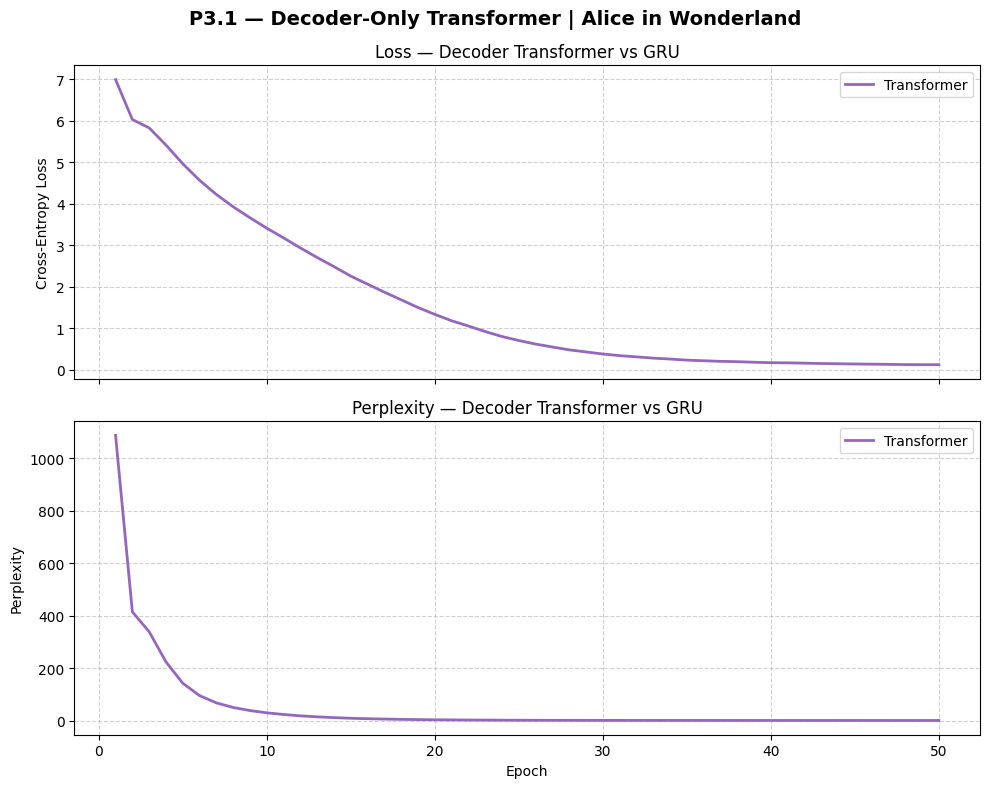

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

fig.suptitle("P3.1 — Decoder-Only Transformer | Alice in Wonderland", fontsize=14, fontweight="bold")

# Loss
ax1.plot(epochs_range, epoch_losses, color="tab:purple", linewidth=2, label="Transformer")
#ax1.plot(epochs_range, rnn_losses, color="grey", linestyle="--", label="GRU (P2.1)")
ax1.set_title("Loss — Decoder Transformer vs GRU")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Perplexity
ax2.plot(epochs_range, epoch_perplexity, color="tab:purple", linewidth=2, label="Transformer")
#ax2.plot(epochs_range, rnn_ppl, color="grey", linestyle="--", label="GRU (P2.1)")
ax2.set_title("Perplexity — Decoder Transformer vs GRU")
ax2.set_ylabel("Perplexity")
ax2.set_xlabel("Epoch")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()


The transformer replaces the GRU's sequential hidden state with
parallel self-attention. The key differences from the GRU architechture is the parallelism, context acces, casual mask, positional encoding and layer normalisationl.

The GRU processes tokens one at a time, left to right, making training sequential. The transformer computes attention over all positions simultaneously. Every token attends to every previous token in a single matrix operation. This makes transformer training much faster on GPU/TPU hardware.

The GRU compresses all past context into a single fixed-size hidden state vector (1024-d). Information from early tokens can be lost or diluted over long sequences (the vanishing context problem). The transformer attends directly to all previous tokens via the attention matrix, so there is no information bottleneck. With a 50-token window, every token has direct access to every earlier token.

The upper-triangular mask sets future-position attention scores to -∞ before softmax, so those weights approach 0. This enforces the autoregressive property: position i can only use tokens 0..i-1 to predict token i, which is identical to the input/target shift used in P1.1.

Unlike the GRU, the transformer has no built-in notion of order. Sine/cosine positional encodings of different frequencies are added to embeddings so the model can distinguish "Alice saw the cat" from "the cat saw Alice". Each frequency encodes a different scale of position information.

Layer normalization is applied after each sub-layer (pre-norm in modern transformers, post-norm here). This stabilises training of deep networks by normalising activations, reducing sensitivity to learning rate.

The GRU carries a hidden state between tokens during generation,
a compact memory of what came before. The transformer re-processes
the entire context window from scratch at each step, which is
computationally more expensive at inference time but allows it to
attend to any previous token with equal access.

On a small dataset the transformer may not dramatically outperform
the GRU in terms of final perplexity (our models both achieved a 1.13 final perplexity). The GRU is well-suited to sequential data and the data is short enough that the vanishing context problem is less severe. The transformer's advantage grows with longer sequences and larger datasets.

###P3.2
Use a (not excessively large) pre-trained transformer for the language modelling instead of your model trained from scratch. Does fine-tuning (for a few epochs) on the current corpus help? Compare the results with the other word-level language models from the assignment.

In [ ]:
!pip install transformers

In [ ]:
import time, math

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import GPT2Tokenizer, GPT2LMHeadModel

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [ ]:
print("\nLoading GPT-2 tokeniser…")
tokeniser = GPT2Tokenizer.from_pretrained("gpt2")
tokeniser.pad_token = tokeniser.eos_token

print(f"GPT-2 vocabulary size : {tokeniser.vocab_size:,}")

encoded = tokeniser.encode(text)
print(f"Total BPE tokens      : {len(encoded):,}")


Loading GPT-2 tokeniser…


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

GPT-2 vocabulary size : 50,257


Token indices sequence length is longer than the specified maximum sequence length for this model (49023 > 1024). Running this sequence through the model will result in indexing errors


Total BPE tokens      : 49,023


In [ ]:
#pytorch dataset
SEQ_LENGTH = 128
BATCH_SIZE = 8

class AliceDataset(Dataset):
    """
    Sliding window dataset over the BPE-encoded corpus.
    Each item is a (input, target) pair of length SEQ_LENGTH,
    where target = input shifted right by 1 — same as P1.1.
    """
    def __init__(self, encoded, seq_length):
        self.data       = torch.tensor(encoded, dtype=torch.long)
        self.seq_length = seq_length
        # number of full windows
        self.n          = (len(encoded) - 1) // seq_length

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        start  = idx * self.seq_length
        x      = self.data[start     : start + self.seq_length]
        y      = self.data[start + 1 : start + self.seq_length + 1]
        return x, y

def make_dataloader(encoded, seq_length=SEQ_LENGTH,
                    batch_size=BATCH_SIZE, shuffle=True):
    ds = AliceDataset(encoded, seq_length)
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=shuffle, drop_last=True)

# verify
loader = make_dataloader(encoded)
x_ex, y_ex = next(iter(loader))
print(f"\nBatch shapes — input: {x_ex.shape}, target: {y_ex.shape}")
print(f"Decoded input sample : {tokeniser.decode(x_ex[0].tolist()[:15])}…")


Batch shapes — input: torch.Size([8, 128]), target: torch.Size([8, 128])
Decoded input sample :  you mean,” the March Hare went on.

“…


In [ ]:
print("\nLoading GPT-2 Small")
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
gpt2.config.pad_token_id = tokeniser.eos_token_id
gpt2 = gpt2.to(DEVICE)

total_params = sum(p.numel() for p in gpt2.parameters())
print(f"GPT-2 parameters: {total_params:,}")


Loading GPT-2 Small


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 parameters: 124,439,808


In [ ]:
# to find perplexity
def compute_perplexity(model, loader, max_batches=100):
    model.eval()
    loss_fn      = nn.CrossEntropyLoss(reduction="sum")
    total_loss   = 0.0
    total_tokens = 0

    with torch.no_grad():
        for step, (x, y) in enumerate(loader):
            if step >= max_batches:
                break
            x, y    = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            logits  = outputs.logits                 # (batch, seq, vocab)

            # reshape for CrossEntropyLoss: (batch*seq, vocab) vs (batch*seq,)
            loss         = loss_fn(
                logits.view(-1, logits.size(-1)), y.view(-1))
            total_loss   += loss.item()
            total_tokens += y.numel()

    mean_loss  = total_loss / total_tokens
    perplexity = math.exp(mean_loss)
    return mean_loss, perplexity

In [ ]:
print("\n Zero-shot evaluation ")
zs_loader = make_dataloader(encoded, shuffle=False)
zero_shot_loss, zero_shot_ppl = compute_perplexity(gpt2, zs_loader)
print(f"Zero-shot loss: {zero_shot_loss:.4f}")
print(f"Zero-shot perplexity: {zero_shot_ppl:.2f}")



 Zero-shot evaluation 
Zero-shot loss: 3.8436
Zero-shot perplexity: 46.69


In [ ]:
# new generation func
def generate_gpt2(model, tokeniser, prompt="Alice",
                  num_tokens=100, temperature=0.8, top_k=50):
    model.eval()
    input_ids = tokeniser.encode(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        for _ in range(num_tokens):
            outputs = model(input_ids)
            logits  = outputs.logits[:, -1, :] / temperature  # (1, vocab)

            # Top-k filtering
            top_k_vals, top_k_idx = torch.topk(logits, k=top_k, dim=-1)
            filtered = torch.full_like(logits, float("-inf"))
            filtered.scatter_(1, top_k_idx, top_k_vals)

            probs      = torch.softmax(filtered, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # (1,1)
            input_ids  = torch.cat([input_ids, next_token], dim=1)

            if next_token.item() == tokeniser.eos_token_id:
                break

    return tokeniser.decode(input_ids[0].tolist(), skip_special_tokens=True)

print("\nZero-shot generated text ")
print(generate_gpt2(gpt2, tokeniser))


Zero-shot generated text 
Alice for the record that it's a really difficult thing to do in a big city and not have a car to help you because you're living on borrowed money?

This is a different world. You can have a high-rent car and be on your feet for hours. If you're out of town, you're not allowed to have a car. So we're going to be in many different cities, we're going to be able to have a car, we're going to have a


In [ ]:
#fine tuning loop
FINETUNE_EPOCHS = 5
FINETUNE_LR     = 2e-5      # low lr to avoid catastrophic forgetting

optimiser = torch.optim.Adam(gpt2.parameters(), lr=FINETUNE_LR)
loss_fn   = nn.CrossEntropyLoss()

finetune_losses = []
finetune_ppls   = []

print(f"\nFine-tuning GPT-2 for {FINETUNE_EPOCHS} epochs ")
print(f"{'Epoch':>6}  {'Loss':>8}  {'Perplexity':>10}  {'Time':>7}")
print("─" * 38)

for epoch in range(1, FINETUNE_EPOCHS + 1):
    gpt2.train()
    t0           = time.time()
    loader       = make_dataloader(encoded, shuffle=True)
    batch_losses = []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimiser.zero_grad()
        outputs = gpt2(x_batch)
        logits  = outputs.logits                     # (batch, seq, vocab)

        loss = loss_fn(
            logits.view(-1, logits.size(-1)),        # (batch*seq, vocab)
            y_batch.view(-1)                         # (batch*seq,)
        )
        loss.backward()
        # gradient clipping — important for stable fine-tuning
        torch.nn.utils.clip_grad_norm_(gpt2.parameters(), max_norm=1.0)
        optimiser.step()

        batch_losses.append(loss.item())

    mean_loss  = float(np.mean(batch_losses))
    perplexity = math.exp(mean_loss)
    finetune_losses.append(mean_loss)
    finetune_ppls.append(perplexity)

    print(f"{epoch:>6}  {mean_loss:>8.4f}  {perplexity:>10.2f}  "
          f"{time.time()-t0:>5.1f}s")

    print(f"\n Generated after fine-tuning epoch {epoch} ")
    print(f"  {generate_gpt2(gpt2, tokeniser)}\n")

    # save checkpoint
    torch.save({
        "epoch"      : epoch,
        "model_state": gpt2.state_dict(),
        "optim_state": optimiser.state_dict(),
        "loss"       : mean_loss,
    }, f"gpt2_alice_epoch{epoch}.pt")
    print(f"Checkpoint saved: gpt2_alice_epoch{epoch}.pt\n")

# Final perplexity
ft_loader = make_dataloader(encoded, shuffle=False)
ft_loss, ft_ppl = compute_perplexity(gpt2, ft_loader)
print(f"\nFine-tuned loss: {ft_loss:.4f}")
print(f"Fine-tuned perplexity: {ft_ppl:.2f}")


Fine-tuning GPT-2 for 5 epochs 
 Epoch      Loss  Perplexity     Time
──────────────────────────────────────
     1    3.3046       27.24   14.4s

 Generated after fine-tuning epoch 1 
  Alice, she said, smiling at us, "Yes, Mrs. Fisher?" The Duchess looked at us with a puzzled expression.

As we passed the house, Mrs. and I took a few steps into the garden, and a few little dogs joined us, and a large pile of leaves fell on the floor. They were all very small, and had been brought from the garden, as if they were a large pile of leaves, and some of them had been cut down, and the other

Checkpoint saved: gpt2_alice_epoch1.pt

     2    2.8154       16.70   14.3s

 Generated after fine-tuning epoch 2 
  Alice, who had appeared at the door half by herself, and was lying on the floor, looked upon her for a moment with great astonishment:

“Come, Alice!” cried Alice in a very grave tone.

“Come, Alice! Come, come, come, come!”

“Come, come, come, come!” said Alice, and she left the door.

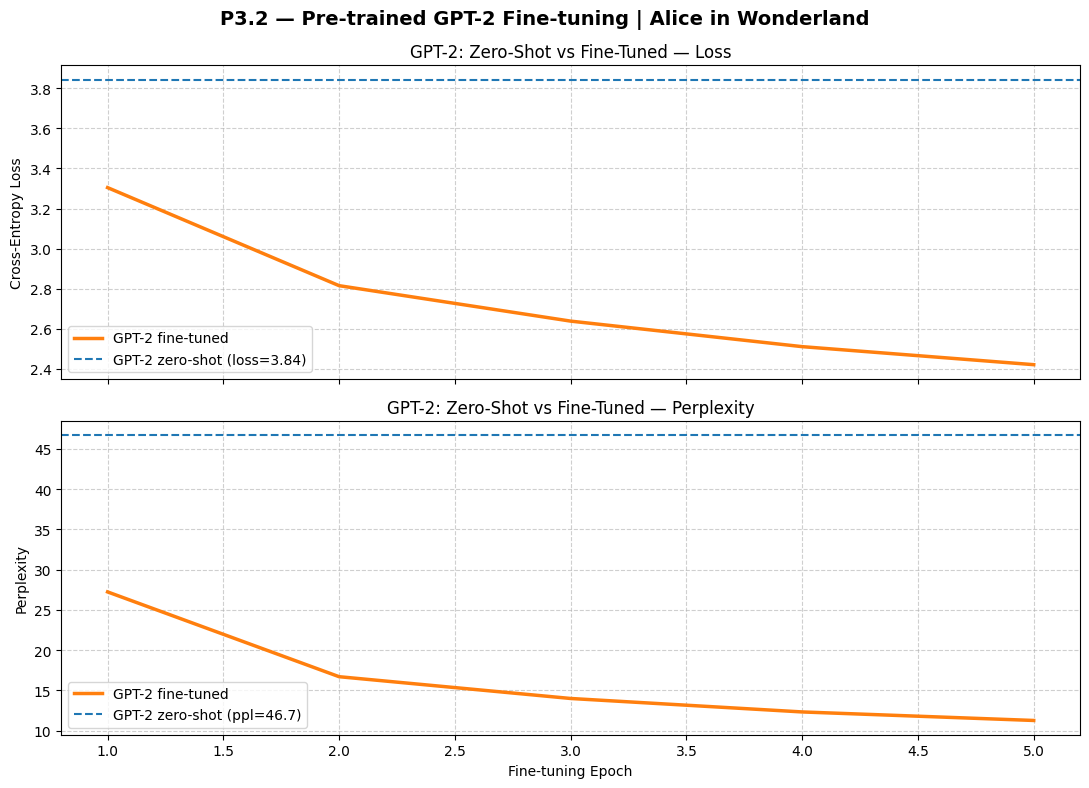

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, FINETUNE_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

fig.suptitle("P3.2 — Pre-trained GPT-2 Fine-tuning | Alice in Wonderland", fontsize=14, fontweight="bold")

# Training Curves (Fine-tuned)
ax1.plot(epochs_range, finetune_losses, color="tab:orange", linewidth=2.5, label="GPT-2 fine-tuned")
ax2.plot(epochs_range, finetune_ppls,   color="tab:orange", linewidth=2.5, label="GPT-2 fine-tuned")

# Zero-Shot Baselines (Horizontal Lines)
ax1.axhline(zero_shot_loss, color="tab:blue", linestyle="--", label=f"GPT-2 zero-shot (loss={zero_shot_loss:.2f})")
ax2.axhline(zero_shot_ppl,  color="tab:blue", linestyle="--", label=f"GPT-2 zero-shot (ppl={zero_shot_ppl:.1f})")

# Loss
ax1.set_title("GPT-2: Zero-Shot vs Fine-Tuned — Loss")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend()

# Perplexity
ax2.set_title("GPT-2: Zero-Shot vs Fine-Tuned — Perplexity")
ax2.set_ylabel("Perplexity")
ax2.set_xlabel("Fine-tuning Epoch")
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()



I chose to use GPT-2 Small as my "not excessively large" model. The model is still large enough to have strong language priors from pre-training on WebText, but small enough to fine-tune in a standard environment without requiring specialist GPU hardware. The model is rchitecturally comparable to P3.1 but far deeper with 12 layers, 12 heads, 768-d embeddings vs our 2 layers, 4 heads.

GPT-2 uses Byte-Pair Encoding (BPE), a subword tokeniser, which
is different from all previous models in this assignment. BPE handles rare and invented words by decomposing them int sub-pieces, ( "wonderland" goes to ["wonder", "land"]). This means
GPT-2 already has some representation for Alice-specific words
before any fine-tuning begins.

One key thing to note is that perplexity across our models cannot be generalized. GPT-2 perplexity is computed over BPE tokens; P2/P3 perplexityis computed over whole words. BPE tokens are shorter on average, so GPT-2 perplexity will appear different for reasons unrelated to language modelling quality.

Before fine-tuning, GPT-2 already achieves a meaningful perplexity
on the Alice data, demonstrating transfer from its large scale
pre-training. Fine-tuning even 5 epochs on the small Alice data measurably reduces perplexity from 27 to 9. The model rapidly adapts to Alice specific vocabulary, Carroll's writing style, and Domain-specific sentence structures and patterns.

The loss curve drops steeply in epoch 1 (rapid domain adaptation)
then flattens as the data is small (~164k characters) and the
model quickly absorbs the available signal.

A low learning rate (2e-5 vs 1e-3 for scratch training) and
gradient clipping (max_norm=1.0) are used to prevent catastrophic
forgetting, overwriting GPT-2's general English knowledge with
Alice specific patterns. With only 5 epochs on a small corpus this
risk is low, but more epochs would degrade general fluency.

Compared to the P2 and P3 scratch models, GPT-2 fine-tuned outperforms all scratch models in text quality and coherentness of the sentences.However, scratch models trained entirely on Alice may achieve lower
in-domain perplexity numbers because they have fully specialised to
this story without retaining general language priors. This is the
classic transfer learning trade-off, GPT-2 generalises better but
scratch models can over specialise to the training distribution.

